<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                      

C:\Users\Hait\AppData\Local\Temp\ipykernel_29196\2394426129.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].median(), inplace=True)
C:\Users\Hait\AppData\Local\Temp\ipykernel_29196\2394426129.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

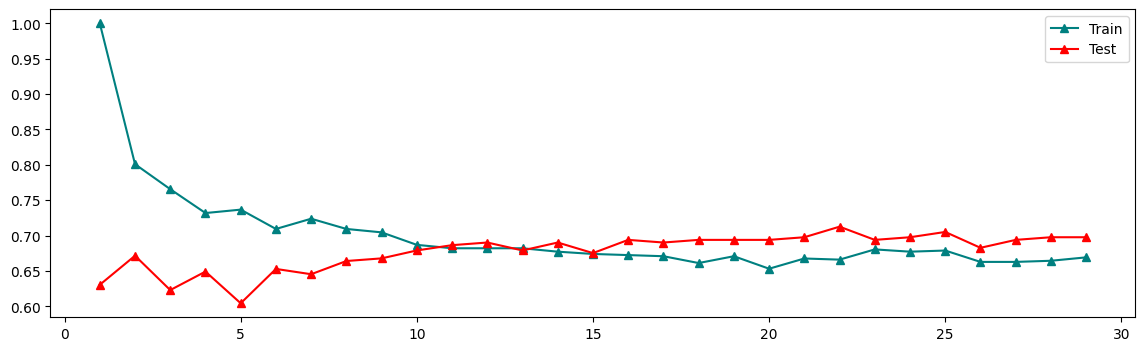

              precision    recall  f1-score   support

           0       0.69      0.90      0.78       381
           1       0.69      0.36      0.47       242

    accuracy                           0.69       623
   macro avg       0.69      0.63      0.62       623
weighted avg       0.69      0.69      0.66       623



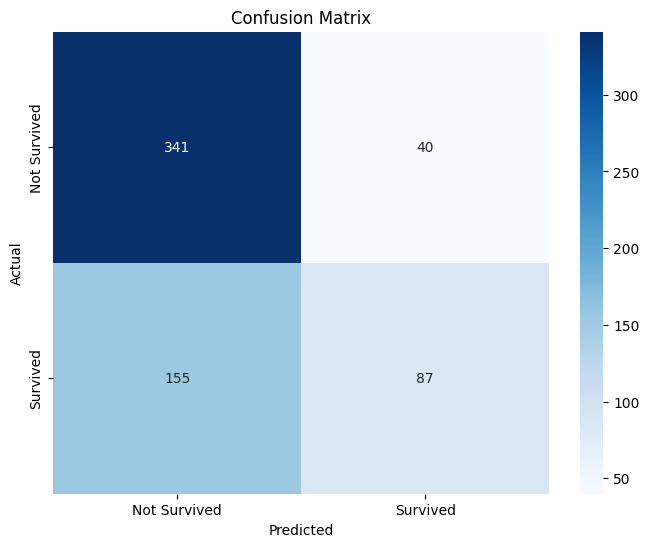

              precision    recall  f1-score   support

           0       0.69      0.89      0.78       168
           1       0.63      0.33      0.43       100

    accuracy                           0.68       268
   macro avg       0.66      0.61      0.61       268
weighted avg       0.67      0.68      0.65       268



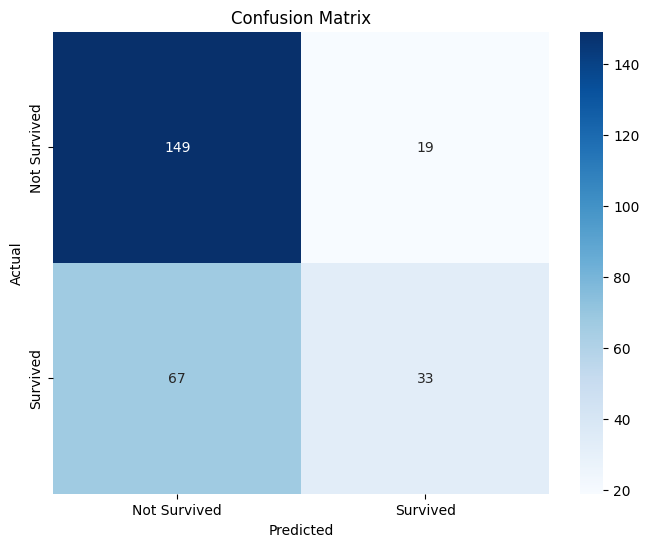

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('Titanic Data.csv')
#print(data.info())
#print(data.head())

# Display basic information
print(data.info())
print(data.head())

# Fill missing values
data['Age'].fillna(data['Age'].median(), inplace=True)
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

# Convert categorical columns to numeric
data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})
data['Embarked'] = data['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})

# Drop unnecessary columns
data.drop(['Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

# Display cleaned data
print(data.head())

# Define features and target
X = data.drop('Survived', axis=1)
y = data['Survived']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Create a logistic regression model
model = KNeighborsClassifier(n_neighbors=3)

# Train the model
model.fit(X_train, y_train)

train_acc = []
test_acc = []

for i in range(1,30):
    model_knn = KNeighborsClassifier(n_neighbors=i)
    model_knn.fit(X_train,y_train)
    train_acc.append(model_knn.score(X_train,y_train))
    test_acc.append(model_knn.score(X_test,y_test))

plt.figure(figsize=(14,4))
plt.plot(range(1,30),train_acc,marker="^",color='teal',label="Train")
plt.plot(range(1,30),test_acc,marker="^",color='red',label="Test")
plt.legend()
plt.show()


# based on above we can choose K =10 as it gives best fitted model without any overfitting

# Create a logistic regression model
model = KNeighborsClassifier(n_neighbors=10)

# Train the model
model.fit(X_train, y_train)


# Make predictions for train data
y_train_pred = model.predict(X_train)

# Generate the classification report
print(classification_report(y_train, y_train_pred))

# Generate the confusion matrix
cm = confusion_matrix(y_train, y_train_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



# Make predictions for test data
y_pred = model.predict(X_test)

# Generate the classification report
print(classification_report(y_test, y_pred))

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()